In [4]:
import tensorflow as tf

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [6]:
dataset = pd.read_csv("Churn_Modelling.csv")

In [7]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
X=dataset.iloc[:, 3:13]
y= dataset.iloc[:, 13]

In [9]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [10]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [12]:
## Feature engineering

geography = pd.get_dummies(X['Geography'], drop_first=True)

In [14]:
gender = pd.get_dummies(X['Gender'], drop_first=True)

In [15]:
X = X.drop(['Geography', 'Gender'], axis = 1)

In [16]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64
9996,516,35,10,57369.61,1,1,1,101699.77
9997,709,36,7,0.00,1,0,1,42085.58
9998,772,42,3,75075.31,2,1,0,92888.52


In [18]:
X = pd.concat([X, geography, gender], axis = 1)

In [19]:
## Splitting the dataset into training and testing dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [20]:
## Feature scaling

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [21]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [22]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [23]:
X_train.shape

(8000, 11)

In [24]:
## Create ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

In [25]:
# Initializing ANN
classifier = Sequential()

In [26]:
## Adding input layer
classifier.add(Dense(units=11, activation='relu'))

In [27]:
# Adding the first Hidden layer
classifier.add(Dense(units=7, activation='relu'))


In [28]:
## Adding second hidden layer
classifier.add(Dense(units=6, activation='relu'))

In [29]:
# Adding output layer
classifier.add(Dense(1, activation='sigmoid'))

In [30]:
classifier.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
## Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [34]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=1000, callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8757 - loss: 0.3078 - val_accuracy: 0.8523 - val_loss: 0.3668
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8695 - loss: 0.3138 - val_accuracy: 0.8482 - val_loss: 0.3784
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8769 - loss: 0.2978 - val_accuracy: 0.8550 - val_loss: 0.3653
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8792 - loss: 0.2970 - val_accuracy: 0.8527 - val_loss: 0.3691
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8674 - loss: 0.3168 - val_accuracy: 0.8519 - val_loss: 0.3664
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8783 - loss: 0.2986 - val_accuracy: 0.8485 - val_loss: 0.3680
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8778 - loss: 0.2971 - val_accuracy: 0.8504 - val_loss: 0.3682
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8726 - loss: 0.3118 - 

In [35]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

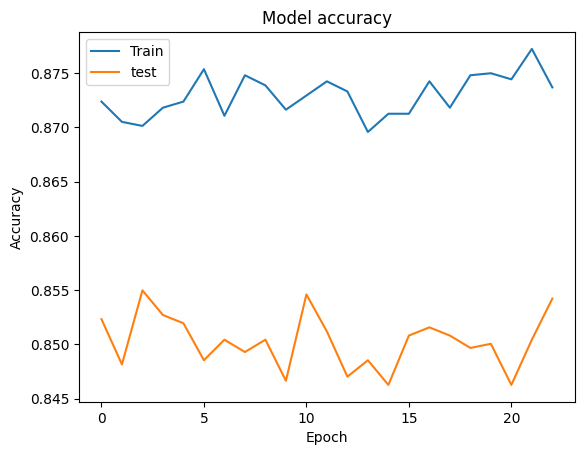

In [36]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'test'], loc = 'upper left')
plt.show()

In [38]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[1512,   83],
       [ 210,  195]])

In [40]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
score

0.8535

In [41]:
## Get the weights
classifier.weights

[<Variable path=sequential/dense/kernel, shape=(11, 11), dtype=float32, value=[[ 0.25759852  0.18754311 -0.04219361 -0.07627431 -0.1629474   0.03458183
   -0.04274771 -0.06438476 -0.0353755   0.05674051 -0.03339021]
  [-0.17343602  0.36630863 -0.62533516  0.03579386 -0.24674144  0.3223498
    0.7504567  -0.8737582  -0.05520264 -0.6030322  -0.08078555]
  [-0.12379729 -0.03598809  0.55404234 -0.45051414 -0.00956086  0.02070393
    0.20860995 -0.16909552  0.02763004 -0.02941249  0.13644567]
  [ 0.05327914  0.63055927 -0.84711707  0.0193259   0.66778916  0.31883055
   -0.6466823   0.09247648  0.18076041 -0.234647   -0.6788069 ]
  [-0.12688102  0.32748     0.04376977 -0.03779241 -0.43565607 -0.6048547
    0.25313714  0.10247418  1.0800884  -0.1903009  -1.4936442 ]
  [-0.4746493   0.12391137 -0.09583502  0.01418197  0.04588913 -0.4470174
   -0.13297667 -0.5270132  -0.13538241  0.00703892 -0.19006494]
  [ 0.3717678  -0.52516973  0.51820683 -1.1198574  -0.15546831  0.26399547
    0.14241336 -0